# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

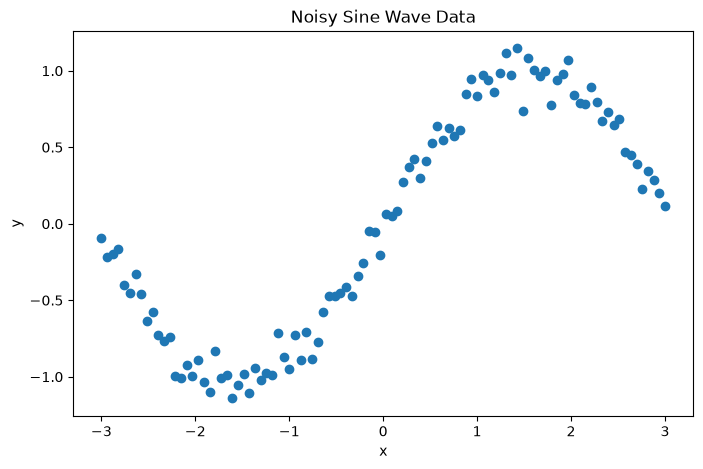

In [2]:
# Generate toy data

x = np.linspace(-3, 3, 100)

y = np.sin(x) + np.random.normal(
    0,
    0.1,
    100
)

plt.figure(figsize=(8,5))

plt.scatter(x, y)

plt.title("Noisy Sine Wave Data")
plt.xlabel("x")
plt.ylabel("y")

plt.show()


In [3]:


w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

print("w =", w)
print("b =", b)


w = -0.14153707420504144
b = -0.04206453227653591


In [4]:
lr = 0.05

losses = []

for step in range(200):

    y_hat = w * x + b

    loss = np.mean((y_hat - y) ** 2)

    dw = np.mean(2 * (y_hat - y) * x)

    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

    losses.append(loss)

print("Final loss:", loss)

Final loss: 0.1954517971396205


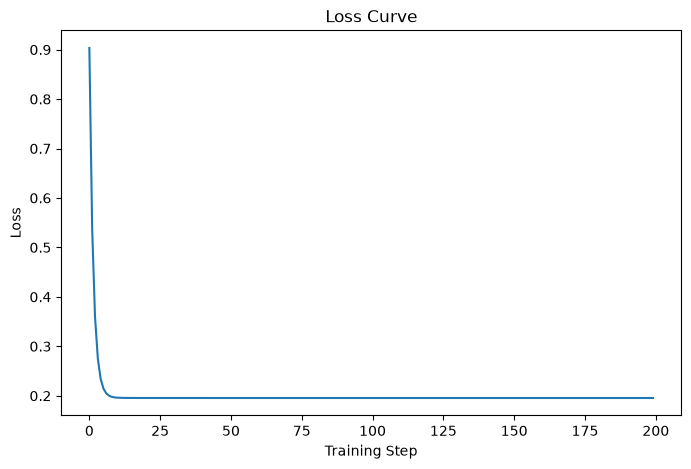

In [5]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.show()

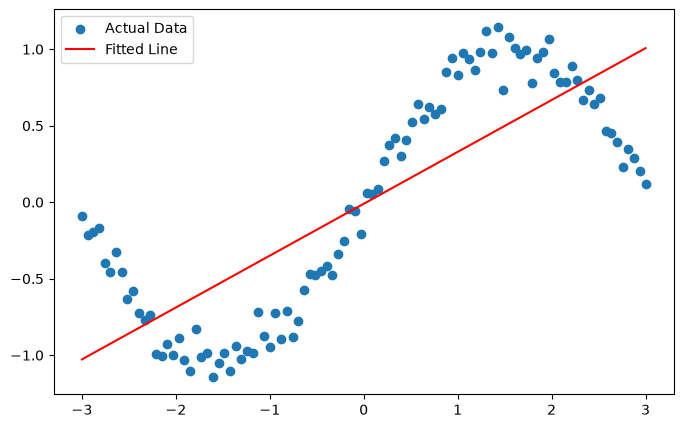

In [6]:
y_hat = w * x + b

plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Actual Data")

plt.plot(
    x,
    y_hat,
    color="red",
    label="Fitted Line"
)

plt.legend()

plt.show()

answer:

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

In [7]:
# Initialize parameters

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

# Reshape data
x_nn = x.reshape(-1, 1)
y_nn = y.reshape(-1, 1)

lr = 0.05

losses = []

# Training loop
for step in range(3000):

    # Forward pass
    z1 = x_nn @ W1 + b1
    h = np.tanh(z1)

    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_nn) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y_nn) / len(y_nn)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x_nn.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

print("Final Loss:", loss)

Final Loss: 0.014841292390220518


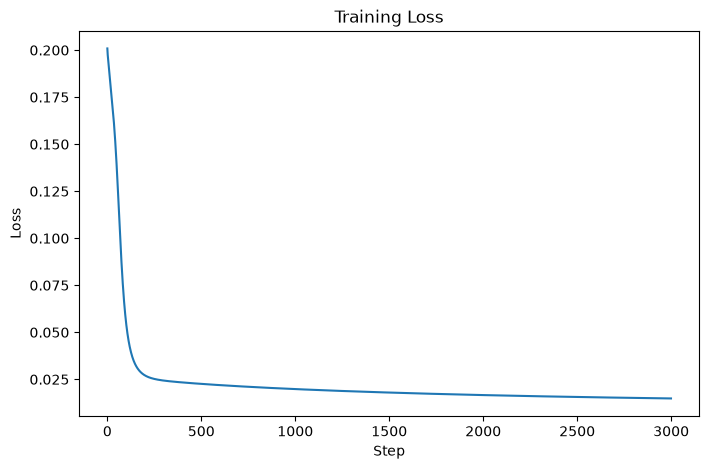

In [8]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")

plt.show()

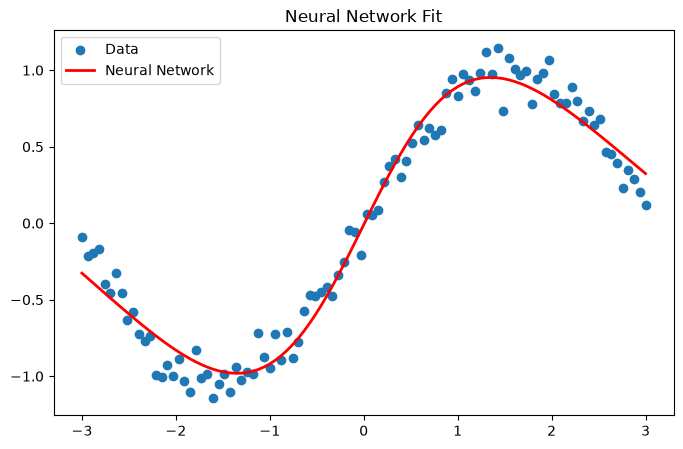

In [9]:
z1 = x_nn @ W1 + b1
h = np.tanh(z1)

y_pred = h @ W2 + b2

plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Data")

plt.plot(
    x,
    y_pred,
    color="red",
    linewidth=2,
    label="Neural Network"
)

plt.legend()
plt.title("Neural Network Fit")

plt.show()

In [10]:
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros((1, 8))

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros((1, 1))

losses_linear = []

for step in range(3000):

    z1 = x_nn @ W1_linear + b1_linear

    h = z1      # tanh removed

    y_hat = h @ W2_linear + b2_linear

    loss = np.mean((y_hat - y_nn) ** 2)

    d_yhat = 2 * (y_hat - y_nn) / len(y_nn)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2_linear.T

    dz1 = dh

    dW1 = x_nn.T @ dz1
    db1 = dz1.sum(axis=0)

    W1_linear -= 0.05 * dW1
    b1_linear -= 0.05 * db1

    W2_linear -= 0.05 * dW2
    b2_linear -= 0.05 * db2

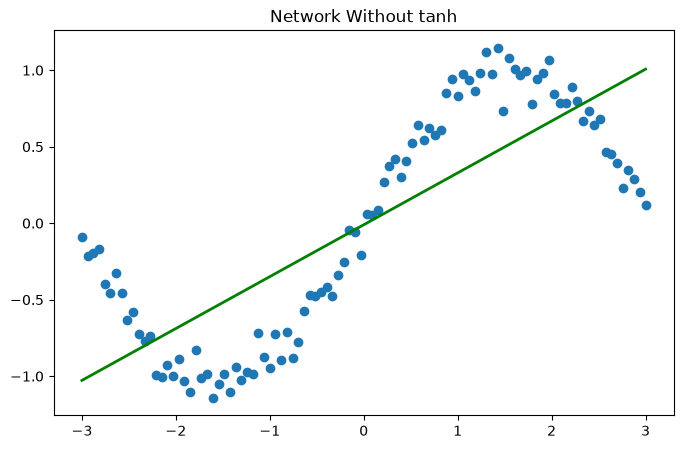

In [11]:
z1 = x_nn @ W1_linear + b1_linear
h = z1

y_pred_linear = h @ W2_linear + b2_linear

plt.figure(figsize=(8,5))

plt.scatter(x, y)

plt.plot(
    x,
    y_pred_linear,
    color="green",
    linewidth=2
)

plt.title("Network Without tanh")

plt.show()

answer-

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** [Double-click to edit]

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

C:\Users\user\AppData\Local\Temp\ipykernel_1600\2070888295.py:20: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_nn) ** 2)
C:\Users\user\AppData\Local\Temp\ipykernel_1600\2070888295.py:27: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\user\AppData\Local\Temp\ipykernel_1600\2070888295.py:29: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


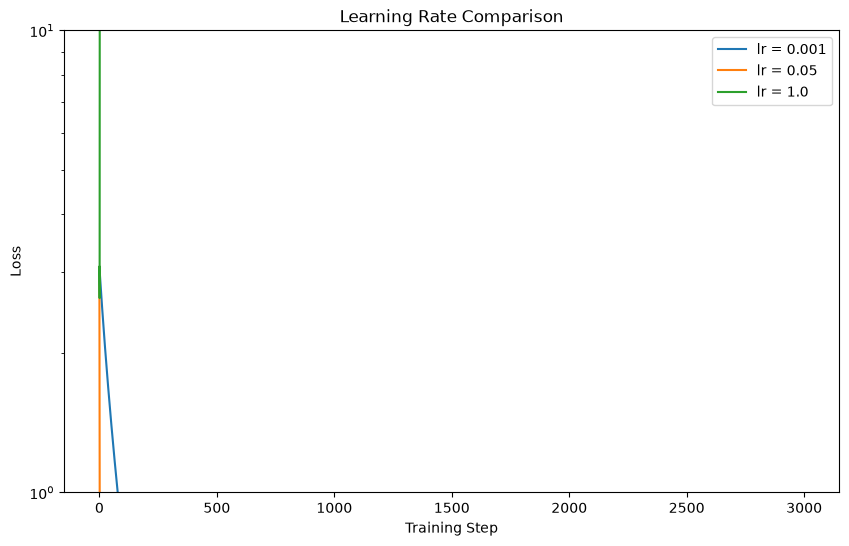

In [13]:
def train_toy(lr, steps=3000):
    
    np.random.seed(42)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))

    losses = []

    for step in range(steps):

        z1 = x_nn @ W1 + b1
        h = np.tanh(z1)

        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y_nn) ** 2)

        d_yhat = 2 * (y_hat - y_nn) / len(y_nn)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T

        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x_nn.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses


loss_small = train_toy(0.001)
loss_good = train_toy(0.05)
loss_large = train_toy(1.0)

plt.figure(figsize=(10, 6))

plt.plot(loss_small, label="lr = 0.001")
plt.plot(loss_good, label="lr = 0.05")
plt.plot(loss_large, label="lr = 1.0")

plt.yscale("log")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")

plt.legend()

plt.show()

answer-

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity = pd.read_csv(OBESITY_URL)

# Feature engineering
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# Binary columns
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_cols:
    obesity[col] = obesity[col].map({
        "yes": 1,
        "no": 0
    })

# One-hot encode categorical columns
obesity = pd.get_dummies(
    obesity,
    columns=[
        "Gender",
        "CAEC",
        "CALC",
        "MTRANS"
    ],
    drop_first=True
)

# Encode target labels
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    obesity["NObeyesdad"]
)

# Features
X = obesity.drop(
    columns=["NObeyesdad"]
)

# Stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 1266
Validation samples: 422
Test samples: 423


answer - 

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [16]:
class FeedForwardNet(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)


# Instantiate model
input_dim = X_train.shape[1]

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
)

# Move model to device
model = model.to(DEVICE)

print(model)

# Count trainable parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTrainable Parameters:", total_params)

# Verify first layer parameter count
first_layer_params = (input_dim * 64) + 64

print("First Layer Parameters:", first_layer_params)


FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Trainable Parameters: 3911
First Layer Parameters: 1600


anSWER-

**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [17]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Tracking metrics
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0

# Training loop
for epoch in range(50):

    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()

    with torch.no_grad():

        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            preds = torch.argmax(logits, dim=1)

            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        train_acc = train_correct / train_total

        val_correct = 0
        val_total = 0
        val_loss_total = 0

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            preds = torch.argmax(logits, dim=1)

            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

            val_loss_total += loss.item()

        val_acc = val_correct / val_total
        val_loss = val_loss_total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )

    print(
        f"Epoch {epoch+1:02d}/50 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/50 | Train Loss: 1.8430 | Val Loss: 1.6892 | Train Acc: 0.4408 | Val Acc: 0.4455
Epoch 02/50 | Train Loss: 1.4859 | Val Loss: 1.2636 | Train Acc: 0.6311 | Val Acc: 0.6303
Epoch 03/50 | Train Loss: 1.0994 | Val Loss: 0.9687 | Train Acc: 0.7077 | Val Acc: 0.7014
Epoch 04/50 | Train Loss: 0.8568 | Val Loss: 0.7962 | Train Acc: 0.7583 | Val Acc: 0.7488
Epoch 05/50 | Train Loss: 0.7006 | Val Loss: 0.6691 | Train Acc: 0.8167 | Val Acc: 0.7844
Epoch 06/50 | Train Loss: 0.5804 | Val Loss: 0.5721 | Train Acc: 0.8404 | Val Acc: 0.8033
Epoch 07/50 | Train Loss: 0.4855 | Val Loss: 0.4903 | Train Acc: 0.8712 | Val Acc: 0.8412
Epoch 08/50 | Train Loss: 0.4089 | Val Loss: 0.4311 | Train Acc: 0.8926 | Val Acc: 0.8602
Epoch 09/50 | Train Loss: 0.3484 | Val Loss: 0.3867 | Train Acc: 0.9210 | Val Acc: 0.8815
Epoch 10/50 | Train Loss: 0.3012 | Val Loss: 0.3536 | Train Acc: 0.9329 | Val Acc: 0.9076
Epoch 11/50 | Train Loss: 0.2592 | Val Loss: 0.3190 | Train Acc: 0.9313 | Val Acc: 0.9028
Epoch 12/5

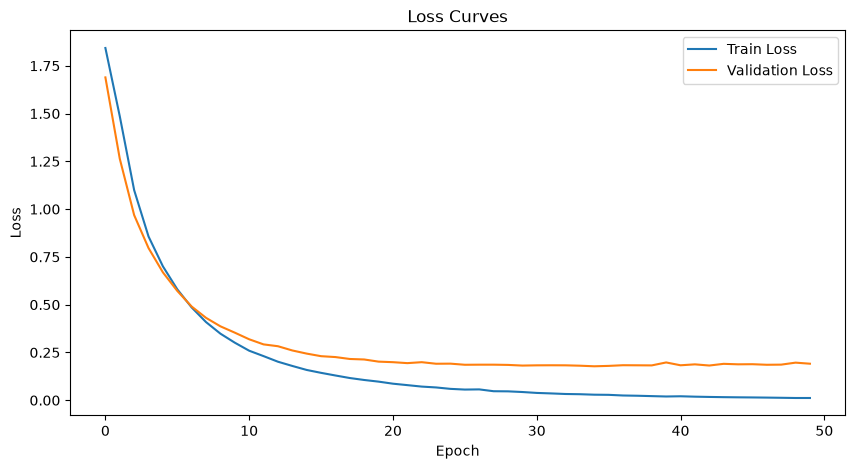

In [18]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

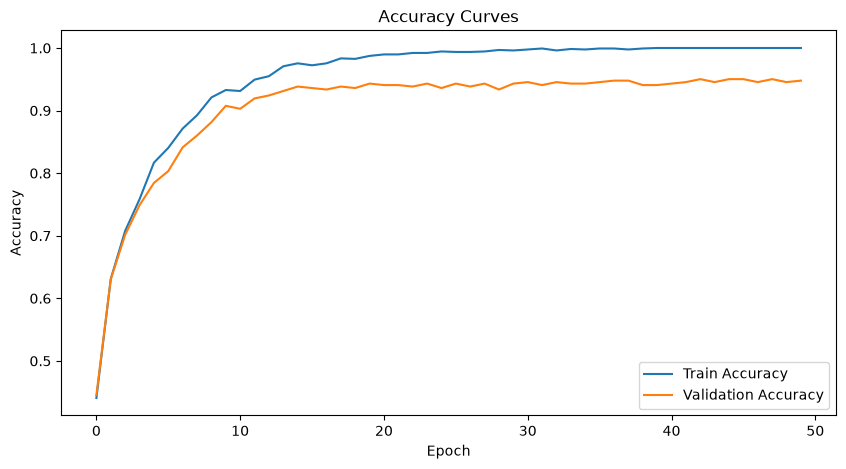

In [19]:
plt.figure(figsize=(10,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

answer-

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [20]:
class ExperimentNet(nn.Module):
    
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0
    ):
        super().__init__()

        layers = []

        prev_dim = input_dim

        for hidden_dim in hidden_sizes:

            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            layers.append(
                nn.ReLU()
            )

            if dropout > 0:
                layers.append(
                    nn.Dropout(dropout)
                )

            prev_dim = hidden_dim

        layers.append(
            nn.Linear(prev_dim, n_classes)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    epochs=50,
    dropout=0.0
):

    model = ExperimentNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()

        with torch.no_grad():

            train_correct = 0
            train_total = 0

            for xb, yb in train_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                preds = torch.argmax(
                    model(xb),
                    dim=1
                )

                train_correct += (preds == yb).sum().item()
                train_total += yb.size(0)

            train_acc = train_correct / train_total

            val_correct = 0
            val_total = 0
            val_loss_sum = 0

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)

                loss = criterion(logits, yb)

                preds = torch.argmax(
                    logits,
                    dim=1
                )

                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

                val_loss_sum += loss.item()

            val_acc = val_correct / val_total
            val_loss = val_loss_sum / len(val_loader)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    return history


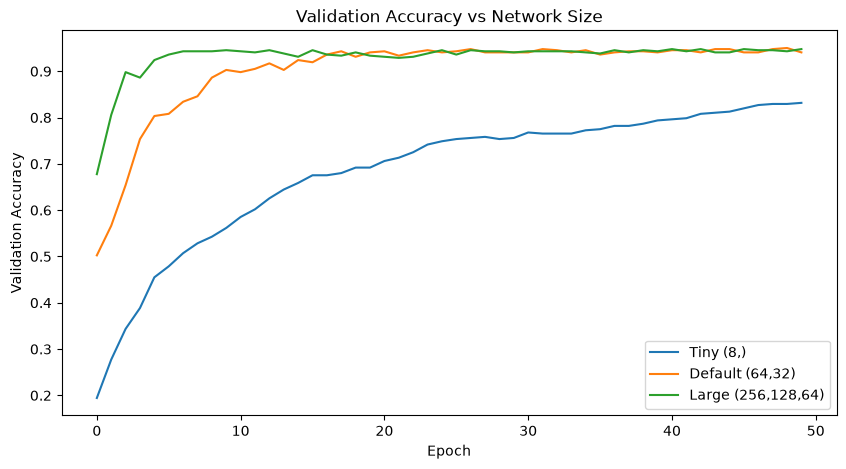

In [21]:
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64, 32))
large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(10,5))

plt.plot(tiny["val_acc"], label="Tiny (8,)")
plt.plot(default["val_acc"], label="Default (64,32)")
plt.plot(large["val_acc"], label="Large (256,128,64)")

plt.title("Validation Accuracy vs Network Size")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.show()

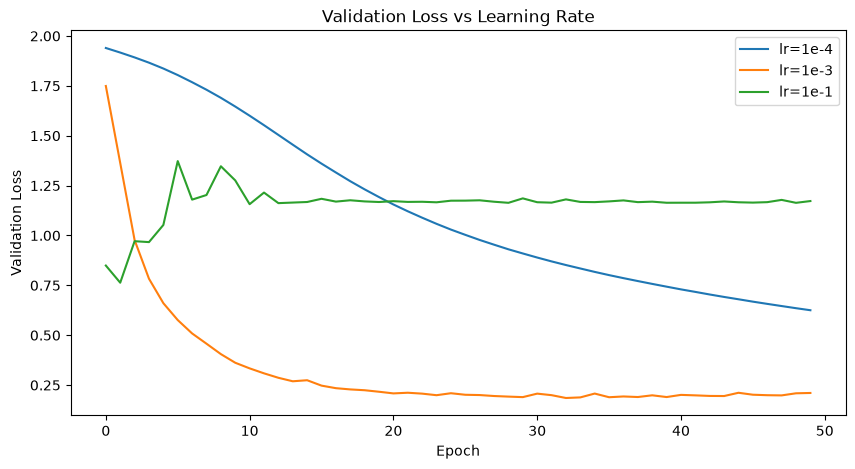

In [22]:
lr_small = run_experiment(lr=1e-4)

lr_default = run_experiment(lr=1e-3)

lr_large = run_experiment(lr=1e-1)

plt.figure(figsize=(10,5))

plt.plot(lr_small["val_loss"], label="lr=1e-4")
plt.plot(lr_default["val_loss"], label="lr=1e-3")
plt.plot(lr_large["val_loss"], label="lr=1e-1")

plt.title("Validation Loss vs Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.show()


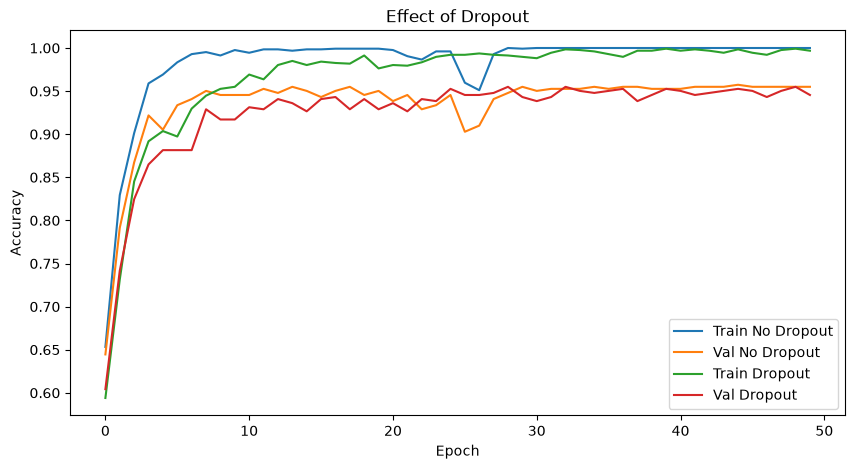

In [23]:
large_no_dropout = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.0
)

large_with_dropout = run_experiment(
    hidden_sizes=(256, 128, 64),
    dropout=0.3
)

plt.figure(figsize=(10,5))

plt.plot(
    large_no_dropout["train_acc"],
    label="Train No Dropout"
)

plt.plot(
    large_no_dropout["val_acc"],
    label="Val No Dropout"
)

plt.plot(
    large_with_dropout["train_acc"],
    label="Train Dropout"
)

plt.plot(
    large_with_dropout["val_acc"],
    label="Val Dropout"
)

plt.title("Effect of Dropout")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

answer-

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.